# --- Model Architecture ---

In [1]:
# =========================================
# Environment Ingestion & Hardware Setup
# =========================================

import os
import sys
import torch
from pathlib import Path
from torchinfo import summary

# Define root workspace paths
BASE_DIR = Path("/teamspace/studios/this_studio/airport-incident-detection")
SRC_DIR = BASE_DIR / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

PROC_DIR = str(BASE_DIR / "data" / "processed")

# Device Management Check
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🔋 Execution Target Device: {device}")
if torch.cuda.is_available():
    print(f"    └── GPU Model Name: {torch.cuda.get_device_name(0)}")

%reload_ext autoreload
%autoreload 2

🔋 Execution Target Device: cuda
    └── GPU Model Name: Tesla T4


In [2]:
# ========================================
# Model Architecture & Layer Dimensions
# ========================================
from models.model import MultiTaskAirportNet

# Initialize the custom structural network
model = MultiTaskAirportNet().to(device)

# print("="*60 + "\n 🔬 CUSTOM MULTI-HEAD APRON DETECTOR ARCHITECTURE SUMMARY\n" + "="*60)
# # print(model)
# print("="*60)

# 2. Print Layer-by-Layer Architectural Matrix Layout
print("\n--- 🔬 CUSTOM MULTI-HEAD YOLO MODEL ARCHITECTURE SUMMARY ---")
model_stats = summary(
    model, 
    # FIX: Remove input_size entirely to bypass the forward execution graph pass
    input_size=(4, 3, 640, 640),
    col_names=["num_params", "trainable"],
    col_width=20,
    row_settings=["depth", "var_names"],
    verbose=0 # Blocks internal dummy tensor flow executions
)
print(model_stats)

--- 🏗️ SYNTHESIZING MULTI-TASK NETWORK ARCHITECTURE ---


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


 Locked early backbone layers successfully.
 All 3 specialized spatial task branches successfully configured.

--- 🔬 CUSTOM MULTI-HEAD YOLO MODEL ARCHITECTURE SUMMARY ---
Layer (type (var_name):depth-idx)                  Param #              Trainable
MultiTaskAirportNet (MultiTaskAirportNet)          --                   Partial
├─Sequential (backbone): 1-1                       --                   Partial
│    └─Conv2d (0): 2-1                             (9,408)              False
│    └─BatchNorm2d (1): 2-2                        (128)                False
│    └─ReLU (2): 2-3                               --                   --
│    └─MaxPool2d (3): 2-4                          --                   --
│    └─Sequential (4): 2-5                         --                   False
│    │    └─BasicBlock (0): 3-1                    (73,984)             False
│    │    └─BasicBlock (1): 3-2                    (73,984)             False
│    └─Sequential (5): 2-6                     

🔋 Execution Target Device: cuda
---🔍 INITIALIZED MULTI-TASK DATASET FOR SPLIT: [TRAIN] ---
✅ Bound Task [0] (turnaround): Registered 17702 frames.
✅ Bound Task [1] (ppe): Registered 20598 frames.
✅ Bound Task [2] (fod): Registered 61518 frames.
📊 Global Dataset Composition: Total registered multi-task sample frames = 99818

--- 🏗️ SYNTHESIZING MULTI-TASK NETWORK ARCHITECTURE ---


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


 Locked early backbone layers successfully.
 All 3 specialized spatial task branches successfully configured.

🚀 Starting Overfitting Test Run (50 Epochs)...
Epoch [01/50] -> Total Loss: 8.356042 | Turnaround Loss: 2.6464 | PPE Loss: 1.7415 | FOD Loss: 3.5482
Epoch [10/50] -> Total Loss: 0.186972 | Turnaround Loss: 0.0796 | PPE Loss: 0.0345 | FOD Loss: 0.0317
Epoch [20/50] -> Total Loss: 0.055222 | Turnaround Loss: 0.0225 | PPE Loss: 0.0114 | FOD Loss: 0.0089
Epoch [30/50] -> Total Loss: 0.027592 | Turnaround Loss: 0.0111 | PPE Loss: 0.0061 | FOD Loss: 0.0036
Epoch [40/50] -> Total Loss: 0.017321 | Turnaround Loss: 0.0069 | PPE Loss: 0.0041 | FOD Loss: 0.0017
Epoch [50/50] -> Total Loss: 0.012837 | Turnaround Loss: 0.0050 | PPE Loss: 0.0031 | FOD Loss: 0.0011
☑️ OVERFITTING TEST PASSED: Model safely optimized small sample batch vector!



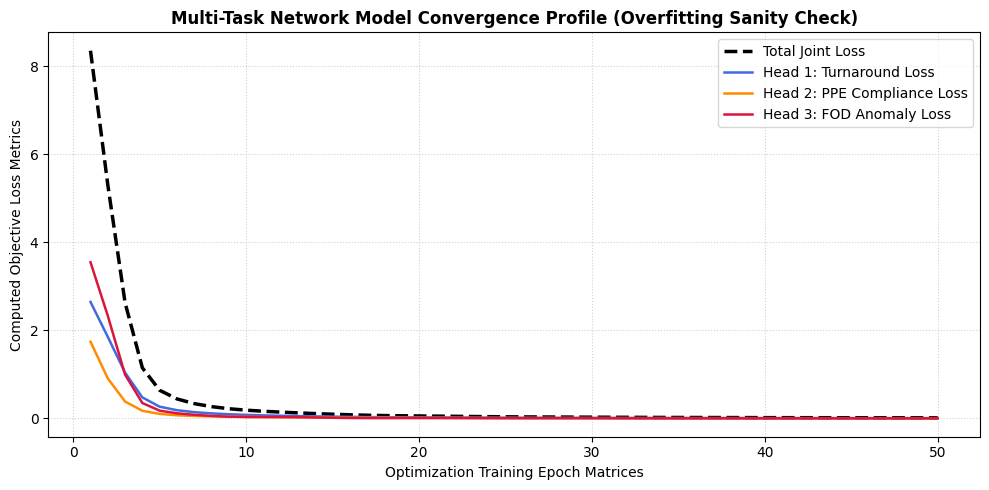

In [3]:
# -----------------------------------------
# Check Model Overfitting on Small sample
# -----------------------------------------
# from models.debug_overfit import run_overfitting_test

# # Invokes your isolated execution loop to run 50 memorization steps on a single batch
# run_overfitting_test()

from models.overfit_test import run_overfitting_check

run_overfitting_check(PROC_DIR)

In [4]:
from models.train import model_train_phase1

model_train_phase1(PROC_DIR)

🚀 Initializing Full-Scale Training Pipeline on Target: cuda
---🔍 INITIALIZED MULTI-TASK DATASET FOR SPLIT: [TRAIN] ---
✅ Bound Task [0] (turnaround): Registered 17702 frames.
✅ Bound Task [1] (ppe): Registered 20598 frames.
✅ Bound Task [2] (fod): Registered 61518 frames.
📊 Global Dataset Composition: Total registered multi-task sample frames = 99818

---🔍 INITIALIZED MULTI-TASK DATASET FOR SPLIT: [VAL] ---
✅ Bound Task [0] (turnaround): Registered 2697 frames.
✅ Bound Task [1] (ppe): Registered 3141 frames.
✅ Bound Task [2] (fod): Registered 9364 frames.
📊 Global Dataset Composition: Total registered multi-task sample frames = 15202

--- 🏗️ SYNTHESIZING MULTI-TASK NETWORK ARCHITECTURE ---
 Locked early backbone layers successfully.
 All 3 specialized spatial task branches successfully configured.

📅 Epoch [1/5]


  Training Progress:   0%|          | 0/6239 [00:00<?, ?it/s]

  Training Progress: 100%|██████████| 6239/6239 [22:23<00:00,  4.64it/s, Total Loss=2.5715] 


    📊 Summary -> Train Loss: 12.9917 | Val Loss: 7.9041
    └─ Heads Breakdown -> Turnaround: 1.6850 | PPE: 4.0231 | FOD: 8.8593
 💾 New optimal validation milestone secured. Checkpoint saved.

📅 Epoch [2/5]


  Training Progress: 100%|██████████| 6239/6239 [22:19<00:00,  4.66it/s, Total Loss=2.2478] 


...

    📊 Summary -> Train Loss: 6.6303 | Val Loss: 6.6029
    └─ Heads Breakdown -> Turnaround: 0.6167 | PPE: 3.6141 | FOD: 0.5683
 💾 New optimal validation milestone secured. Checkpoint saved.

📅 Epoch [4/5]


  Training Progress: 100%|██████████| 6239/6239 [22:19<00:00,  4.66it/s, Total Loss=7.5947] 


    📊 Summary -> Train Loss: 6.0173 | Val Loss: 5.7859
    └─ Heads Breakdown -> Turnaround: 0.4576 | PPE: 3.4253 | FOD: 0.3857
 💾 New optimal validation milestone secured. Checkpoint saved.

📅 Epoch [5/5]


  Training Progress: 100%|██████████| 6239/6239 [22:18<00:00,  4.66it/s, Total Loss=8.1629] 


    📊 Summary -> Train Loss: 5.4375 | Val Loss: 5.5401
    └─ Heads Breakdown -> Turnaround: 0.3476 | PPE: 3.1813 | FOD: 0.2882
 💾 New optimal validation milestone secured. Checkpoint saved.

☑️ Training Sequence Concluded Successfully.
